In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from pyproj import Proj, Transformer, Geod
import xarray as xr
import earthaccess

In [2]:
# 1. Authenticate
auth = earthaccess.login()

In [3]:
# 2. Search for Antarctic ATL15 V5 files
granules = earthaccess.search_data(
    short_name="ATL15",
    version="005",
    cloud_hosted=True,
    bounding_box=(-180, -90, 180, -60)
)

print(f"Found {len(granules)} granules.")

Found 16 granules.


In [4]:
granules[7]

Collection: {'EntryTitle': 'ATLAS/ICESat-2 L3B Gridded Antarctic and Arctic Land Ice Height Change V005'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -55.98787, 'Latitude': -61.21014}, {'Longitude': -55.49655, 'Latitude': -61.5582}, {'Longitude': -57.17232, 'Latitude': -62.12756}, {'Longitude': -57.75166, 'Latitude': -61.76461}, {'Longitude': -59.58058, 'Latitude': -61.88364}, {'Longitude': -61.0743, 'Latitude': -62.56179}, {'Longitude': -60.82995, 'Latitude': -62.97929}, {'Longitude': -64.75053, 'Latitude': -64.34859}, {'Longitude': -66.12999, 'Latitude': -65.35286}, {'Longitude': -67.53948, 'Latitude': -66.06261}, {'Longitude': -69.57484, 'Latitude': -67.10448}, {'Longitude': -70.24585, 'Latitude': -67.95582}, {'Longitude': -67.91785, 'Latitude': -68.23399}, {'Longitude': -68.64983, 'Latitude': -69.10867}, {'Longitude': -70.85803, 'Latitude': -68.48976}, {'Longitude': -72.87379, 'Latitude': -68.76814}, {'Longitude': -73.85505, 'Latitude': -69.46974}, {'Longitude': -76.90514, 'Latitude': -69.63695}, {'Longitude': -76.45108, 'Latitude': -70.44757}, {'Longitude': -77.68849, 'Latitude': -70.91016}, {'Longitude': -77.19191, 'Latitude': -71.46406}, {'Longitude': -76.06721, 'Latitude': -71.56426}, {'Longitude': -76.40994, 'Latitude': -72.03561}, {'Longitude': -73.8672, 'Latitude': -72.68982}, {'Longitude': -80.65808, 'Latitude': -72.11701}, {'Longitude': -82.9808, 'Latitude': -73.42043}, {'Longitude': -87.68739, 'Latitude': -72.51699}, {'Longitude': -90.0, 'Latitude': -72.51699}, {'Longitude': -90.0, 'Latitude': -89.5}, {'Longitude': 0.0, 'Latitude': -89.5}, {'Longitude': 0.0, 'Latitude': -69.24335}, {'Longitude': -0.07714, 'Latitude': -69.24335}, {'Longitude': -3.7256, 'Latitude': -69.8819}, {'Longitude': -11.23758, 'Latitude': -70.52587}, {'Longitude': -13.21476, 'Latitude': -71.30518}, {'Longitude': -19.7848, 'Latitude': -72.27668}, {'Longitude': -22.21417, 'Latitude': -73.62914}, {'Longitude': -25.39569, 'Latitude': -73.34863}, {'Longitude': -27.94568, 'Latitude': -74.82236}, {'Longitude': -29.47188, 'Latitude': -75.9791}, {'Longitude': -35.82631, 'Latitude': -77.20026}, {'Longitude': -38.08856, 'Latitude': -77.79085}, {'Longitude': -47.86943, 'Latitude': -77.26947}, {'Longitude': -51.69493, 'Latitude': -76.29059}, {'Longitude': -59.48768, 'Latitude': -74.799}, {'Longitude': -58.4914, 'Latitude': -72.18004}, {'Longitude': -59.9572, 'Latitude': -69.332}, {'Longitude': -59.41862, 'Latitude': -65.66881}, {'Longitude': -56.53213, 'Latitude': -64.61753}, {'Longitude': -56.32692, 'Latitude': -63.92548}, {'Longitude': -54.33081, 'Latitude': -63.51753}, {'Longitude': -54.51458, 'Latitude': -61.21596}, {'Longitude': -55.00194, 'Latitude': -60.88152}, {'Longitude': -55.98787, 'Latitude': -61.21014}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2019-01-01T00:04:55.000Z', 'EndingDateTime': '2025-11-20T00:01:18.513Z'}}
Size(MB): 1949.0742378234863
Data: ['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/ATLAS/ATL15/005/2019/01/01/ATL15_A2_0329_01km_005_02.nc']

In [5]:
print(granules[7])

Collection: {'EntryTitle': 'ATLAS/ICESat-2 L3B Gridded Antarctic and Arctic Land Ice Height Change V005'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -55.98787, 'Latitude': -61.21014}, {'Longitude': -55.49655, 'Latitude': -61.5582}, {'Longitude': -57.17232, 'Latitude': -62.12756}, {'Longitude': -57.75166, 'Latitude': -61.76461}, {'Longitude': -59.58058, 'Latitude': -61.88364}, {'Longitude': -61.0743, 'Latitude': -62.56179}, {'Longitude': -60.82995, 'Latitude': -62.97929}, {'Longitude': -64.75053, 'Latitude': -64.34859}, {'Longitude': -66.12999, 'Latitude': -65.35286}, {'Longitude': -67.53948, 'Latitude': -66.06261}, {'Longitude': -69.57484, 'Latitude': -67.10448}, {'Longitude': -70.24585, 'Latitude': -67.95582}, {'Longitude': -67.91785, 'Latitude': -68.23399}, {'Longitude': -68.64983, 'Latitude': -69.10867}, {'Longitude': -70.85803, 'Latitude': -68.48976}, {'Longitude': -72.87379, 'Latitude': -68.76814}, {'Longitude':

In [7]:
# 3. Stream the granule in-memory
file_obj = earthaccess.open([granules[7]])

ds = xr.open_dataset(
    file_obj[0],
    group="delta_h",
    engine="h5netcdf"
)

# 4. Extract the time of interest
# delta_h represents elevation change relative to 2020.0
ds_t = ds["delta_h"].isel(time=0) # or time=-1 for the latest

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
print(ds_t)
#print(ds_t.attrs["description"])

<xarray.DataArray 'delta_h' (y: 2271, x: 2671)> Size: 24MB
[6065841 values with dtype=float32]
Coordinates:
  * x        (x) float64 21kB -2.67e+06 -2.669e+06 -2.668e+06 ... -1e+03 0.0
  * y        (y) float64 18kB 0.0 1e+03 2e+03 ... 2.268e+06 2.269e+06 2.27e+06
    time     datetime64[ns] 8B 2019-01-01T06:00:00
Attributes:
    least_significant_digit:  4
    units:                    meters
    dimensions:               time,y,x
    datatype:                 float32
    description:              Height change relative to the datum (Jan 1, 202...
    long_name:                height change  at 1 km
    source:                   ATBD section 3.4
    grid_mapping:             Polar_Stereographic


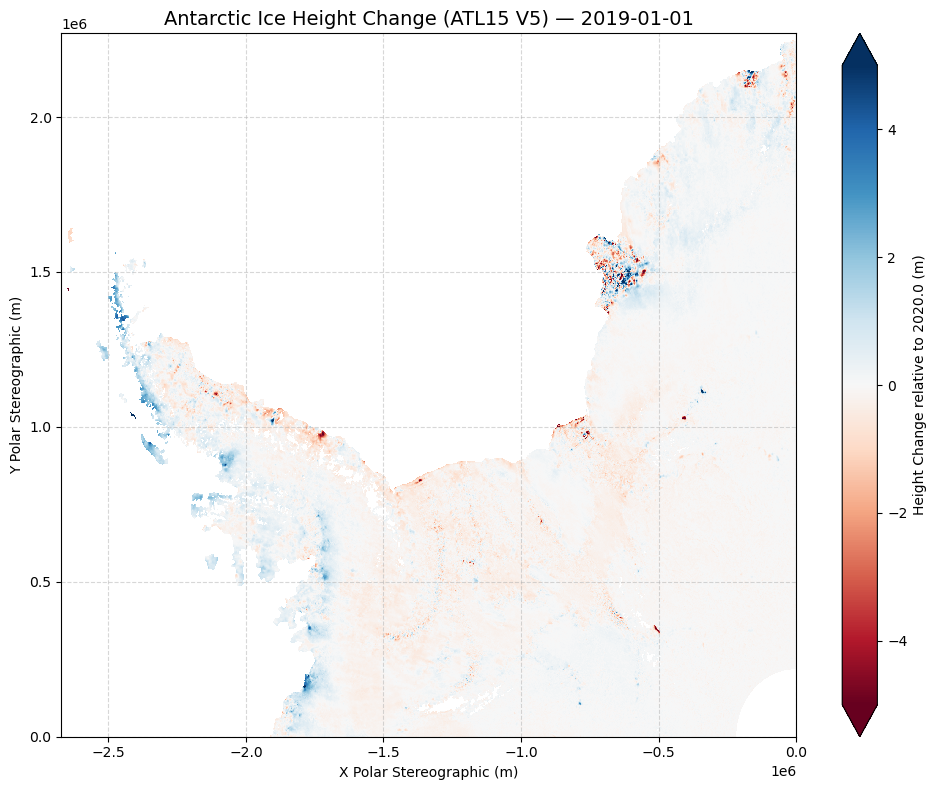

In [9]:
# 5. Plot the Elevation Change Map
fig, ax = plt.subplots(figsize=(10, 8))

ds_t.plot(
    ax=ax,
    cmap="RdBu",
    vmin=-5,             # Scale limits
    vmax=5,
    cbar_kwargs={"label": "Height Change relative to 2020.0 (m)"}
)

time_str = str(ds_t.time.values)[:10]
ax.set_title(f"Antarctic Ice Height Change (ATL15 V5) — {time_str}", fontsize=14)
ax.set_xlabel("X Polar Stereographic (m)")
ax.set_ylabel("Y Polar Stereographic (m)")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()